| **Team Member**               | **Contributions**                                                                                                                                                         |
|-------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Urjeet Parmar**             | - Preprocessed image dataset (resizing, normalization, encoding labels).<br>- Built DNN model with dense layers, dropout, and softmax for multi-class classification.<br>- Implemented model evaluation metrics (accuracy, precision, recall, F1-score).<br>- Performed hyperparameter tuning (learning rate adjustments, dropout regularization). |
| **Rutul Mayankbhai Prajapati**   | - Integrated ResNet50 for transfer learning (freezing base layers, adding custom dense layers).<br>- Implemented image preprocessing for ResNet (Resizing to 224×224, applying ResNet-specific preprocessing).<br>- Evaluated models using advanced metrics (AUC-ROC curve, confusion matrix, MCC, Cohen's Kappa, Jaccard Score).<br>- Visualized model performance using ROC curves, confusion matrices, and performance summaries. |


**Prompts Used:**  
1. "How do I preprocess and resize images for ResNet50?"  
2. "I am getting a ValueError while computing AUC. How can I fix it?"  
3. "Can you help me build a DNN model for multi-class image classification?"  
4. "Why am I getting an IndexError while flattening my image dataset?"  
5. "How do I plot an AUC-ROC curve for multi-class classification?"  
6. "What metrics should I use to evaluate my ResNet50 model performance?"  
7. "How do I import image label from json file?"

1.Importing All Libraries

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

# scikit-learn for preprocessing, evaluation and kNN
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import label_binarize
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.metrics import roc_auc_score

from sklearn.metrics import (
    confusion_matrix, accuracy_score, classification_report, roc_auc_score, 
    log_loss, matthews_corrcoef, cohen_kappa_score, hamming_loss, 
    jaccard_score, balanced_accuracy_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import confusion_matrix, roc_auc_score, classification_report

2.Loading Dataset and Checking Paths

In [2]:
json_path = "photos.json"  
image_dir = r"E:\YelpPhotos\photos"  # Folder with .jpg files

# Load the JSON file
df = pd.read_json(json_path, lines=True)

# Create full image paths
df['image_path'] = df['photo_id'].apply(lambda x: os.path.join(image_dir, f"{x}.jpg"))

# Check if files exist
df['exists'] = df['image_path'].apply(os.path.exists)
missing_files = df[~df['exists']]
if not missing_files.empty:
    print("\n⚠️ Warning: Some image files are missing! Here are the first 5 missing files:")
    display(missing_files[['photo_id', 'image_path']].head())
else:
    print("\n✅ All image paths are valid!")


df.drop(columns=['exists'], inplace=True)

print("\nFirst 5 valid image paths:")
display(df[['photo_id', 'image_path']].head())



✅ All image paths are valid!

First 5 valid image paths:


,photo_id,image_path
0,zsvj7vloL4L5jhYyPIuVwg,E:\YelpPhotos\photos\zsvj7vloL4L5jhYyPIuVwg.jpg
1,HCUdRJHHm_e0OCTlZetGLg,E:\YelpPhotos\photos\HCUdRJHHm_e0OCTlZetGLg.jpg
2,vkr8T0scuJmGVvN2HJelEA,E:\YelpPhotos\photos\vkr8T0scuJmGVvN2HJelEA.jpg
3,pve7D6NUrafHW3EAORubyw,E:\YelpPhotos\photos\pve7D6NUrafHW3EAORubyw.jpg
4,H52Er-uBg6rNrHcReWTD2w,E:\YelpPhotos\photos\H52Er-uBg6rNrHcReWTD2w.jpg


3.Took 10K Samples of image to work with.

In [3]:
SAMPLE_SIZE = 10000  
df_small = df.head(SAMPLE_SIZE).copy()

print(f"Using {len(df_small)} images for this first step.")


Using 10000 images for this first step.


4.This function loads an image, converts it to RGB, resizes it to 64×64 pixels, and returns it as a NumPy array for further processing; if an error occurs, it returns None.

In [4]:
IMG_SIZE = (64, 64)

def preprocess_image(image_path):
    try:
        img = Image.open(image_path).convert('RGB')
        img = img.resize(IMG_SIZE)
        return np.array(img)  
    except Exception as e:
        return None  


5.This code loads images and labels from df_small, converts them into NumPy arrays X (images) and y (labels), and prints their shapes.

In [5]:
X_list = []
y_list = []

for idx, row in df_small.iterrows():
    img_array = preprocess_image(row["image_path"])
    if img_array is not None:
        X_list.append(img_array)
        y_list.append(row["label"]) 

X = np.array(X_list, dtype='float32')
y = np.array(y_list)

print("Shape of X:", X.shape) 
print("Shape of y:", y.shape)


Shape of X: (9998, 64, 64, 3)
Shape of y: (9998,)


6.This code splits the data into training (80%) and testing (20%) sets and prints their shapes.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)


Train set: (7998, 64, 64, 3) (7998,)
Test set: (2000, 64, 64, 3) (2000,)


7.This code normalizes pixel values of the images in X_train and X_test to the range [0, 1] for better model performance and confirms normalization with a print statement.

In [7]:
# Normalize pixel values to [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Data normalized.")


Data normalized.


8.This code flattens the images from 3D (height, width, channels) to 2D arrays for DNN input and prints the new shapes of X_train_flat and X_test_flat.

In [8]:
# Flatten images
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("X_train_flat shape:", X_train_flat.shape)
print("X_test_flat shape:", X_test_flat.shape)


X_train_flat shape: (7998, 12288)
X_test_flat shape: (2000, 12288)


In [9]:
print(f"Number of training samples: {X_train.shape[0]}")


Number of training samples: 7998


In [10]:
print("y_train shape:", y_train.shape)
print("Unique labels:", np.unique(y_train))


y_train shape: (7998,)
Unique labels: ['drink' 'food' 'inside' 'menu' 'outside']


9.This code converts string labels to integer labels using LabelEncoder, applies the encoding to both training and testing labels, and displays the mapping of original labels to their corresponding integers.

In [12]:
from sklearn.preprocessing import LabelEncoder

# Encode string labels to integers
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Check the mapping
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label Mapping:", label_mapping)


Label Mapping: {np.str_('drink'): np.int64(0), np.str_('food'): np.int64(1), np.str_('inside'): np.int64(2), np.str_('menu'): np.int64(3), np.str_('outside'): np.int64(4)}


10.This code **builds a Deep Neural Network (DNN)** with multiple dense and dropout layers for multi-class classification, **compiles the model** using the Adam optimizer and sparse categorical cross-entropy loss, and **displays the model architecture summary**.

In [13]:
# Input dimension (flattened image size)
input_dim = X_train_flat.shape[1]  
num_classes = len(np.unique(y_train_encoded))  

# Build the DNN
model = Sequential([
    Dense(512, activation='relu', input_shape=(input_dim,)),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # Softmax for multi-class classification
])


model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  
    metrics=['accuracy']
)

# Model summary
model.summary()


e:\YelpPhotos\yelp_env\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,456,837 (24.63 MB)

 Trainable params: 6,456,837 (24.63 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(
    X_train_flat,
    y_train_encoded,     # Using integer-encoded labels
    epochs=10,          
    batch_size=64,     
    validation_split=0.2,
    verbose=2
)


Epoch 1/10
100/100 - 6s - 60ms/step - accuracy: 0.4870 - loss: 1.7285 - val_accuracy: 0.5612 - val_loss: 1.0674
Epoch 2/10
100/100 - 5s - 49ms/step - accuracy: 0.5614 - loss: 1.1011 - val_accuracy: 0.6431 - val_loss: 1.0340
Epoch 3/10
100/100 - 5s - 46ms/step - accuracy: 0.5686 - loss: 1.0753 - val_accuracy: 0.6644 - val_loss: 1.0411
Epoch 4/10
100/100 - 5s - 45ms/step - accuracy: 0.5791 - loss: 1.0422 - val_accuracy: 0.6656 - val_loss: 1.0916
Epoch 5/10
100/100 - 5s - 47ms/step - accuracy: 0.5717 - loss: 1.0537 - val_accuracy: 0.6706 - val_loss: 1.0220
Epoch 6/10
100/100 - 5s - 46ms/step - accuracy: 0.5866 - loss: 1.0204 - val_accuracy: 0.6575 - val_loss: 1.0363
Epoch 7/10
100/100 - 5s - 45ms/step - accuracy: 0.5941 - loss: 1.0164 - val_accuracy: 0.6006 - val_loss: 1.0942
Epoch 8/10
100/100 - 5s - 45ms/step - accuracy: 0.6155 - loss: 0.9949 - val_accuracy: 0.5050 - val_loss: 1.1369
Epoch 9/10
100/100 - 5s - 46ms/step - accuracy: 0.6363 - loss: 0.9660 - val_accuracy: 0.6463 - val_loss:

In [53]:
# Evaluate on the training set
train_loss, train_acc = model.evaluate(X_train_flat, y_train_encoded, verbose=0)

# Evaluate on the test set
test_loss, test_acc = model.evaluate(X_test_flat, y_test_encoded, verbose=0)

# Print the results
print(f"✅ Training Accuracy: {train_acc:.4f}")
print(f"✅ Test Accuracy: {test_acc:.4f}")


✅ Training Accuracy: 0.6064
✅ Test Accuracy: 0.5995


In [16]:
# Predict probabilities
y_probs = model.predict(X_test_flat)  # Shape: (num_samples, num_classes)

# Get predicted class indices
y_pred_classes = np.argmax(y_probs, axis=1)

# Convert predicted indices back to original labels
y_pred_labels = label_encoder.inverse_transform(y_pred_classes)

# Check sample predictions
print("Sample Predictions:", y_pred_labels[:5])


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Sample Predictions: ['inside' 'food' 'inside' 'inside' 'inside']


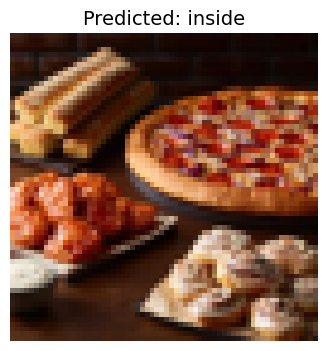

In [17]:
# Select the first test image
sample_index =18 
sample_image = X_test[sample_index]
sample_label = y_pred_labels[sample_index]

# Display the image with the predicted label
plt.figure(figsize=(4, 4))
plt.imshow(sample_image)
plt.title(f"Predicted: {sample_label}", fontsize=14)
plt.axis('off')
plt.show()


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


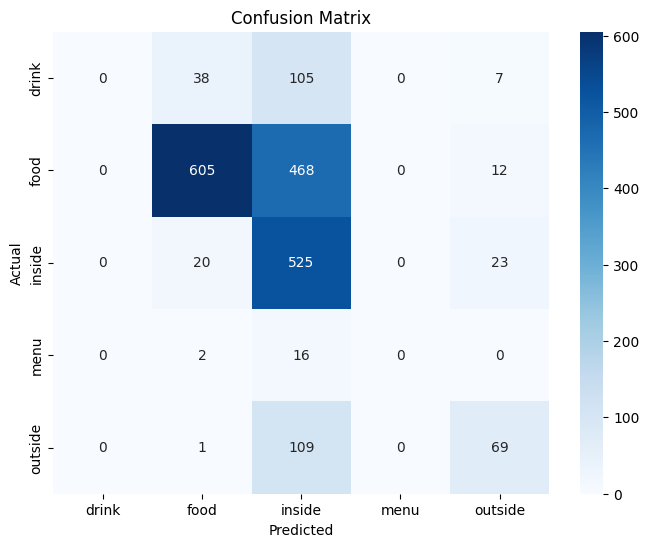

In [58]:
from sklearn.metrics import (
    confusion_matrix, accuracy_score, classification_report,
    precision_score, recall_score, f1_score, roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Predict probabilities for each class
y_probs = model.predict(X_test_flat)  # Output: (num_samples, num_classes)

# Get predicted class indices
y_pred_classes = np.argmax(y_probs, axis=1)

# Generate Confusion Matrix
cm = confusion_matrix(y_test_encoded, y_pred_classes)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [63]:
# Accuracy
accuracy = accuracy_score(y_test_encoded, y_pred_classes)

# Precision, Recall, F1-Score (Macro Average)
precision = precision_score(y_test_encoded, y_pred_classes, average='macro')
recall = recall_score(y_test_encoded, y_pred_classes, average='macro')
f1 = f1_score(y_test_encoded, y_pred_classes, average='macro')

# AUC Score (for Multi-class Classification)
try:
    auc = roc_auc_score(y_test_encoded, y_probs, multi_class='ovr', average='macro')
except ValueError:
    auc = "N/A"

# Display Metrics
print(f" Accuracy: {accuracy:.4f}")
print(f" Precision (Macro Avg): {precision:.4f}")
print(f" Recall (Macro Avg): {recall:.4f}")
print(f" F1-Score (Macro Avg): {f1:.4f}")
print(f" AUC (Macro Avg): {auc if auc != 'N/A' else 'N/A'}")


 Accuracy: 0.5995
 Precision (Macro Avg): 0.3919
 Recall (Macro Avg): 0.3735
 F1-Score (Macro Avg): 0.3506
 AUC (Macro Avg): 0.7102564748713307


e:\YelpPhotos\yelp_env\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


 Macro-Averaged AUC: 0.7103


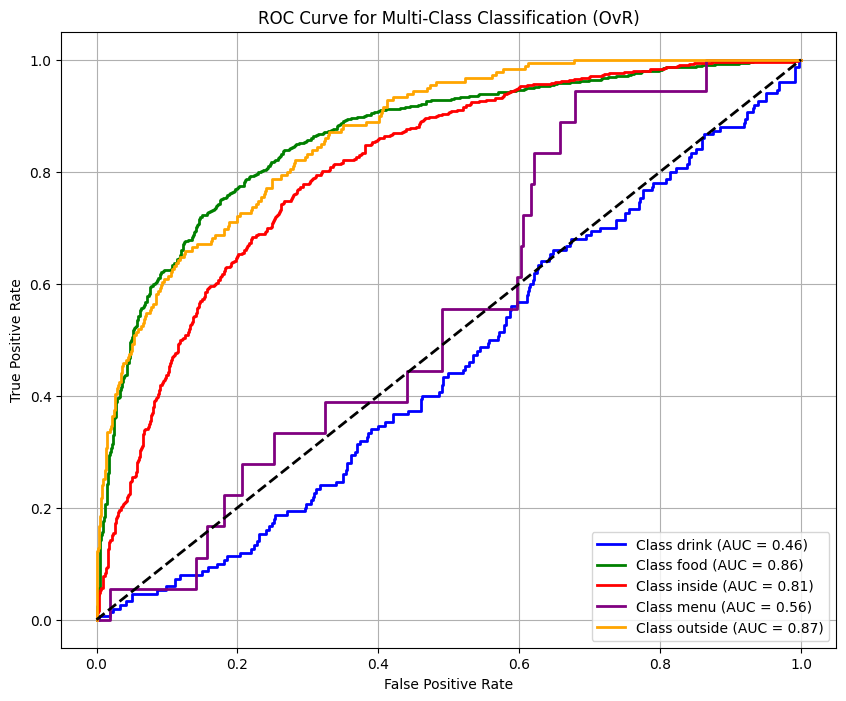

In [64]:
from itertools import cycle


# AUC for multi-class (one-vs-rest)
try:
    auc_score = roc_auc_score(
        y_test_encoded,
        y_probs,
        average='macro',
        multi_class='ovr'
    )
    print(f" Macro-Averaged AUC: {auc_score:.4f}")
except ValueError as e:
    print(f" Could not compute AUC: {e}")


# Binarize the output labels for multi-class ROC
from sklearn.preprocessing import label_binarize

# Binarize the labels (required for ROC curve)
y_test_binarized = label_binarize(y_test_encoded, classes=np.unique(y_test_encoded))
n_classes = y_test_binarized.shape[1]

# Colors for different classes
colors = cycle(['blue', 'green', 'red', 'purple', 'orange'])

# Plot ROC curve for each class
plt.figure(figsize=(10, 8))

for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_probs[:, i])
    auc_class = roc_auc_score(y_test_binarized[:, i], y_probs[:, i])
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"Class {label_encoder.classes_[i]} (AUC = {auc_class:.2f})")

# Plot random chance line
plt.plot([0, 1], [0, 1], 'k--', lw=2)

# Plot formatting
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Multi-Class Classification (OvR)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [20]:
from sklearn.metrics import classification_report

# Generate classification report
report = classification_report(y_test_encoded, y_pred_classes, target_names=label_encoder.classes_)
print("Classification Report:\n")
print(report)


Classification Report:

              precision    recall  f1-score   support

       drink       0.00      0.00      0.00       150
        food       0.91      0.56      0.69      1085
      inside       0.43      0.92      0.59       568
        menu       0.00      0.00      0.00        18
     outside       0.62      0.39      0.48       179

    accuracy                           0.60      2000
   macro avg       0.39      0.37      0.35      2000
weighted avg       0.67      0.60      0.58      2000



e:\YelpPhotos\yelp_env\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
e:\YelpPhotos\yelp_env\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
e:\YelpPhotos\yelp_env\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
